# 4 · Evaluation and explainability

All code is written out in this notebook.

1. Load the trained model
2. Predict the **test set** (patients the model has never seen)
3. Compute the metrics step by step: accuracy, sensitivity, F1, ROC / AUC
4. **Grad-CAM**: which part of the image did the model look at?

## 1. Imports and settings

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm.auto import tqdm
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- folders (this notebook lives in notebooks/, the project root is one level up)
ROOT = Path("..").resolve()
ENHANCED_DIR = ROOT / "data" / "enhanced"     # ODTWCHE-enhanced images (notebook 02)
MASKS_DIR = ROOT / "data" / "masks"           # tumour outlines drawn by radiologists
SPLITS_DIR = ROOT / "data" / "splits"         # train.csv / val.csv / test.csv (notebook 01)
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["benign", "malignant"]
IMAGE_SIZE = 299            # Inception V3 expects 299 x 299 images
BATCH_SIZE = 16

## 2. Test dataset (same class as in notebook 03, without augmentation)

In [3]:
# ImageNet mean / std: the pre-trained network was trained on images normalised like this
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class MRIDataset(Dataset):
    """Reads the images listed in train.csv / val.csv / test.csv."""

    def __init__(self, split, augment=False):
        self.df = pd.read_csv(SPLITS_DIR / f"{split}.csv")
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def load_image(self, i):
        img = cv2.imread(str(ENHANCED_DIR / self.df.file[i]), cv2.IMREAD_GRAYSCALE)
        return cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

    def __getitem__(self, i):
        img = self.load_image(i)

        if self.augment:                                  # data augmentation (paper Sec. 3.1)
            img = np.rot90(img, k=np.random.randint(4))   # rotate 0 / 90 / 180 / 270 degrees
            if np.random.rand() < 0.5:
                img = np.fliplr(img)                      # horizontal flip
            if np.random.rand() < 0.5:
                img = np.flipud(img)                      # vertical flip

        x = np.stack([img, img, img], axis=-1)            # grey -> 3 channels (network expects RGB)
        x = x.astype(np.float32) / 255.0                  # 0..255 -> 0..1
        x = (x - MEAN) / STD                              # ImageNet normalisation
        x = torch.from_numpy(x.transpose(2, 0, 1).copy()) # (H, W, C) -> (C, H, W)
        y = int(self.df.label[i])                         # 0 = benign, 1 = malignant
        return x, y

In [4]:
test_ds = MRIDataset("test")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print("test images:", len(test_ds), "  patients:", test_ds.df.patient.nunique())
print(test_ds.df["class"].value_counts().to_dict())

test images: 94   patients: 20
{'benign': 47, 'malignant': 47}


## 3. Load the trained model
We build the **same architecture** as in notebook 03 (without downloading ImageNet weights),
then load the weights we saved during training.

In [5]:
def build_model(pretrained=True):
    # 1. load Inception V3 (with ImageNet weights when pretrained=True)
    model = models.inception_v3(weights="DEFAULT" if pretrained else None,
                                aux_logits=True, init_weights=not pretrained)

    # 2. freeze every layer
    for p in model.parameters():
        p.requires_grad = False

    # 3. replace the last layer: 1000 ImageNet classes -> 2 classes (benign / malignant)
    model.fc = nn.Sequential(nn.Dropout(0.2),           # dropout 0.2 (paper)
                             nn.Linear(2048, 2))
    model.AuxLogits.fc = nn.Linear(768, 2)              # the small auxiliary classifier too

    # 4. un-freeze the last two Inception blocks so they can adapt to MRI images
    for block in [model.Mixed_7b, model.Mixed_7c, model.AuxLogits]:
        for p in block.parameters():
            p.requires_grad = True
    return model

In [6]:
model = build_model(pretrained=False)
model.load_state_dict(torch.load(MODELS_DIR / "inception_v3.pt"))
model.eval()                        # evaluation mode: no dropout, fixed BatchNorm
print("model loaded")

model loaded


## 4. Predict the test set
`softmax` turns the 2 raw outputs into probabilities that add up to 1.
We keep **P(malignant)**; if it is ≥ 0.5 the prediction is *malignant*.

In [7]:
y_true, y_prob = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader):
        probs = torch.softmax(model(x), dim=1)      # shape (batch, 2)
        y_prob += probs[:, 1].tolist()              # probability of "malignant"
        y_true += y.tolist()

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)
print("first 10 true labels :", y_true[:10])
print("first 10 predictions :", y_pred[:10])

  0%|          | 0/6 [00:00<?, ?it/s]

 17%|█▋        | 1/6 [00:04<00:23,  4.60s/it]

 33%|███▎      | 2/6 [00:09<00:18,  4.54s/it]

 50%|█████     | 3/6 [00:13<00:13,  4.64s/it]

 67%|██████▋   | 4/6 [00:18<00:09,  4.63s/it]

 83%|████████▎ | 5/6 [00:23<00:04,  4.72s/it]

100%|██████████| 6/6 [00:27<00:00,  4.62s/it]

100%|██████████| 6/6 [00:27<00:00,  4.63s/it]

first 10 true labels : [0 0 0 0 0 0 0 0 0 0]
first 10 predictions : [1 0 1 1 0 1 0 0 0 0]


## 5. Metrics

**Confusion matrix** (rows = truth, columns = prediction):

| | predicted benign | predicted malignant |
|---|---|---|
| **true benign** | TB (correct) | benign → malignant (error) |
| **true malignant** | malignant → benign (error, the dangerous one!) | TM (correct) |

* **Accuracy** = correct / all
* **Sensitivity benign** = TB / all benign → how many benign tumours we found
* **Sensitivity malignant** = TM / all malignant → how many malignant tumours we found.
  In medicine this matters most: a missed malignant tumour means a patient without treatment.
* **Precision** = TM / all predicted malignant
* **F1** = balance of precision and sensitivity

In [8]:
TB = np.sum((y_true == 0) & (y_pred == 0))     # benign, predicted benign
BM = np.sum((y_true == 0) & (y_pred == 1))     # benign, predicted malignant   (false alarm)
MB = np.sum((y_true == 1) & (y_pred == 0))     # malignant, predicted benign   (missed tumour!)
TM = np.sum((y_true == 1) & (y_pred == 1))     # malignant, predicted malignant

accuracy = (TB + TM) / len(y_true)
sensitivity_benign = TB / (TB + BM)
sensitivity_malignant = TM / (TM + MB)
precision = TM / (TM + BM)
f1 = 2 * precision * sensitivity_malignant / (precision + sensitivity_malignant)
auc = roc_auc_score(y_true, y_prob)

results = pd.Series({"accuracy": accuracy, "sensitivity benign": sensitivity_benign,
                     "sensitivity malignant": sensitivity_malignant,
                     "precision": precision, "F1": f1, "ROC AUC": auc}).round(3)
results.to_csv(RESULTS_DIR / "test_metrics.csv", header=["value"])
results

accuracy                 0.851
sensitivity benign       0.851
sensitivity malignant    0.851
precision                0.851
F1                       0.851
ROC AUC                  0.940
dtype: float64

Paper (all 3064 images, GPU, 30 epochs): accuracy 98.89 %, sensitivity benign 96.89 %, sensitivity malignant 97.45 %.

**ROC curve:** instead of one threshold (0.5), try *every* threshold and plot
true positive rate (malignant found) against false positive rate (benign wrongly called malignant).
**AUC** = area under this curve: 1.0 = perfect, 0.5 = random guessing.

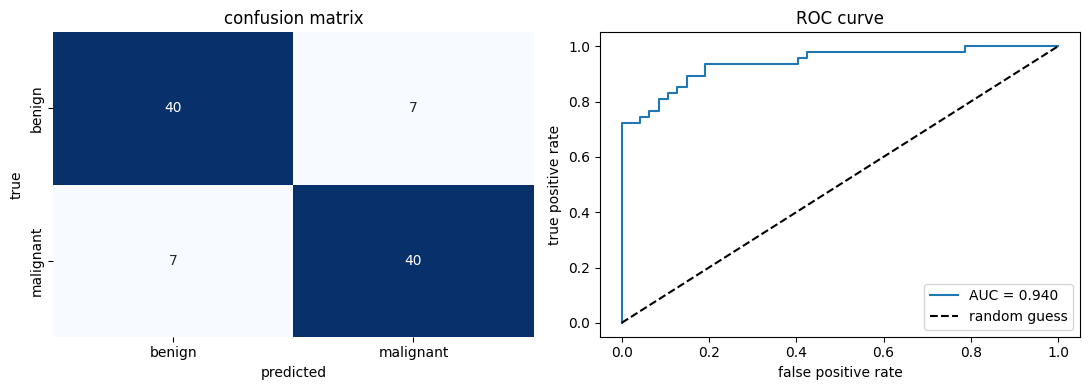

In [9]:
cm = np.array([[TB, BM], [MB, TM]])
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")
axes[0].set_title("confusion matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="random guess")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "evaluation.png", dpi=100)

## 6. Grad-CAM: where does the model look?

Doctors will not trust a "black box". **Grad-CAM** shows which image regions drove a prediction:

1. take the feature maps of the last convolutional block (`Mixed_7c`, 2048 maps of 8×8)
2. compute the gradient of the predicted class score with respect to those maps
3. average each map's gradient → an importance weight per map
4. weighted sum of the maps, keep positive values (ReLU), resize to the image size

We use **hooks** to capture the feature maps and gradients while the image passes through the network.

In [10]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model.eval()
        layer.register_forward_hook(self.save_activations)       # runs during the forward pass

    def save_activations(self, module, inputs, output):
        self.activations = output                                 # feature maps, (1, 2048, 8, 8)
        output.register_hook(self.save_gradients)                 # runs during backward()

    def save_gradients(self, grad):
        self.gradients = grad                                     # same shape as the feature maps

    def __call__(self, x):
        x = x.unsqueeze(0).requires_grad_(True)                   # add batch dimension
        logits = self.model(x)
        pred = int(logits.argmax(dim=1))
        self.model.zero_grad()
        logits[0, pred].backward()                                # gradient of the predicted class

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # step 3: one weight per map
        cam = (weights * self.activations).sum(dim=1)             # step 4: weighted sum
        cam = torch.relu(cam).squeeze().detach().numpy()
        cam = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        cam = cam / (cam.max() + 1e-8)                            # scale to 0..1
        return cam, pred


gradcam = GradCAM(model, model.Mixed_7c)

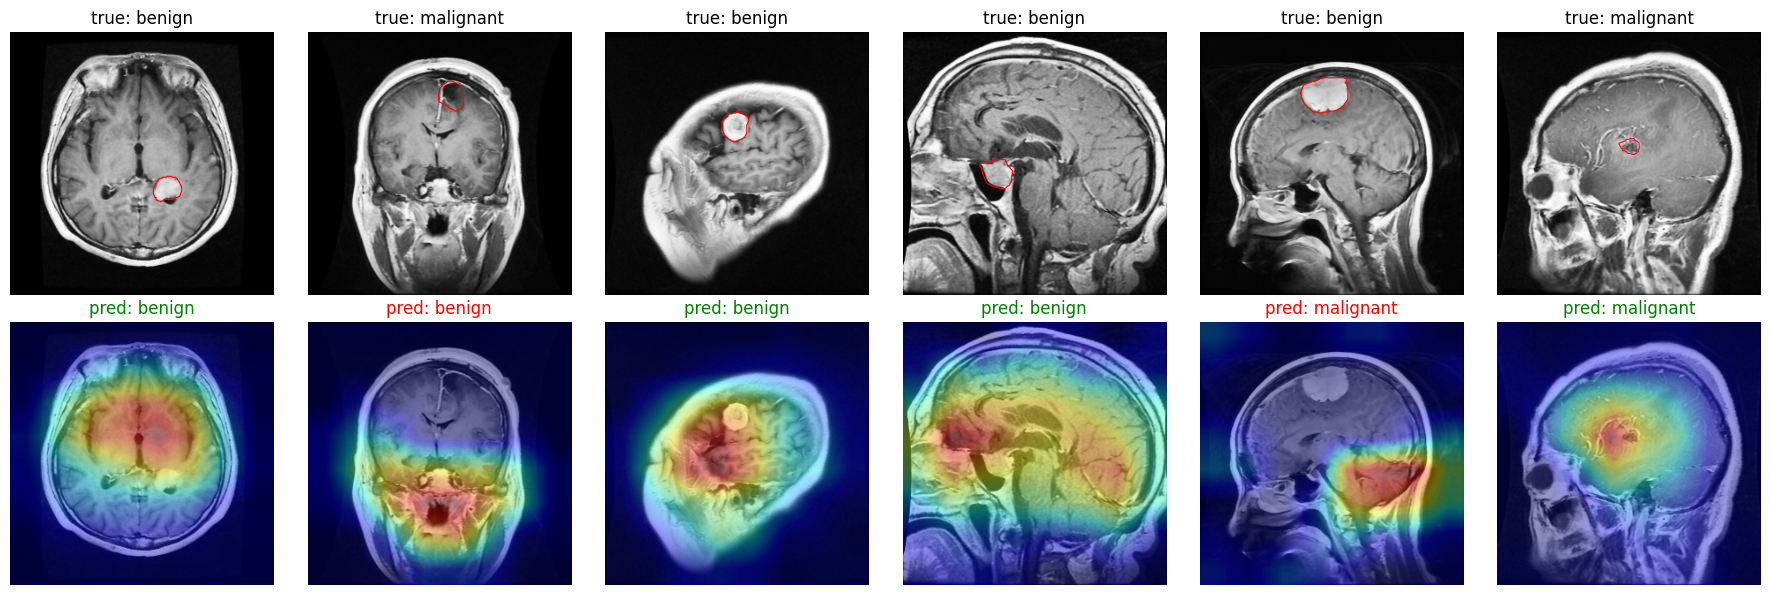

In [11]:
rng = np.random.default_rng(0)
indices = rng.choice(len(test_ds), 6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, i in enumerate(indices):
    x, y = test_ds[i]
    heatmap, pred = gradcam(x)
    img = test_ds.load_image(i)
    mask = cv2.imread(str(MASKS_DIR / test_ds.df.file[i]), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE)) > 0

    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].contour(mask, colors="red", linewidths=0.8)       # radiologist's tumour outline
    axes[0, col].set_title(f"true: {CLASS_NAMES[y]}")

    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].imshow(heatmap, cmap="jet", alpha=0.4)            # red = important for the model
    axes[1, col].set_title(f"pred: {CLASS_NAMES[pred]}", color="green" if pred == y else "red")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gradcam.png", dpi=100)

Top row: MRI with the radiologist's tumour outline (red). Bottom row: Grad-CAM heat-map.

A trustworthy model's heat-map should cover the tumour. When it highlights something else (for example the
skull base, where pituitary tumours usually are), the model has learned a **shortcut** from the tumour *location*
instead of its appearance. That is a known risk in medical imaging and a good point to discuss in the project report.